In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio
from matcha.models.matcha_tts import MatchaTTS
from matcha.text import text_to_sequence
from matcha.utils.utils import intersperse

# FIX 1: Manually define denormalize since the import is failing
def denormalize(mel, mean, std):
    return (mel * std) + mean

In [2]:
import math
import torch
import math
from matcha.models.matcha_tts import MatchaTTS

CHECKPOINT_PATH = "/rds/general/user/ak8224/home/emoji_project/emojivoice/Matcha-TTS/logs/emoji/anger_v1/checkpoints/last-v4.ckpt"

# 1. Load the model
model = MatchaTTS.load_from_checkpoint(
    CHECKPOINT_PATH, 
    map_location="cpu", 
    strict=False,
    n_vocab=198, 
    n_spks=1, 
    spk_emb_dim=0,
    weights_only=False
)

# 2. Fix the Loops (n_layers, n_heads)
def fix_loops(module):
    for attr in ['n_layers', 'n_heads', 'kernel_size']:
        if hasattr(module, attr):
            val = getattr(module, attr)
            if isinstance(val, (list, tuple)):
                setattr(module, attr, int(val[0]))
    if hasattr(module, 'children'):
        for child in module.children():
            fix_loops(child)

fix_loops(model)

# 3. Fix LayerNorm and ensure its 'channels' is a tuple of one integer
for m in model.modules():
    if 'LayerNorm' in m.__class__.__name__:
        if hasattr(m, 'channels'):
            if isinstance(m.channels, int):
                m.channels = (m.channels,)
            elif isinstance(m.channels, list):
                m.channels = tuple(m.channels)

# 4. Final Core Overrides
model.n_feats = 80
model.encoder.n_feats = 80

# 5. Fix Statistics
model.mel_mean = torch.tensor(model.mel_mean).view(1, -1, 1) if not torch.is_tensor(model.mel_mean) else model.mel_mean
model.mel_std = torch.tensor(model.mel_std).view(1, -1, 1) if not torch.is_tensor(model.mel_std) else model.mel_std

model.eval()

/rds/general/user/ak8224/home/miniforge3/envs/emojivoice/lib/python3.10/site-packages/diffusers/models/lora.py:391: FutureWarning: `LoRACompatibleLinear` is deprecated and will be removed in version 1.0.0. Use of `LoRACompatibleLinear` is deprecated. Please switch to PEFT backend by installing PEFT: `pip install peft`.
  deprecate("LoRACompatibleLinear", "1.0.0", deprecation_message)


MatchaTTS(
  (encoder): TextEncoder(
    (emb): Embedding(198, 192)
    (prenet): ConvReluNorm(
      (conv_layers): ModuleList(
        (0-2): 3 x Conv1d(192, 192, kernel_size=5, stride=(1,), padding=(2,))
      )
      (norm_layers): ModuleList(
        (0-2): 3 x LayerNorm()
      )
      (relu_drop): Sequential(
        (0): ReLU()
        (1): Dropout(p=0.5, inplace=False)
      )
      (proj): Conv1d(192, 192, kernel_size=1, stride=(1,))
    )
    (encoder): Encoder(
      (drop): Dropout(p=0.1, inplace=False)
      (attn_layers): ModuleList(
        (0-5): 6 x MultiHeadAttention(
          (conv_q): Conv1d(192, 192, kernel_size=1, stride=(1,))
          (conv_k): Conv1d(192, 192, kernel_size=1, stride=(1,))
          (conv_v): Conv1d(192, 192, kernel_size=1, stride=(1,))
          (query_rotary_pe): RotaryPositionalEmbeddings()
          (key_rotary_pe): RotaryPositionalEmbeddings()
          (conv_o): Conv1d(192, 192, kernel_size=1, stride=(1,))
          (drop): Dropout(p=0.1,

In [3]:
from matcha.text.symbols import symbols

_symbol_to_id = {s: i for i, s in enumerate(symbols)}

def speak(text, temperature=0.667, length_scale=1.0):
    try:
        text = text.lower()
        # Direct character to ID mapping
        raw_seq = [_symbol_to_id.get(s, 1) for s in text]
        inter_seq = intersperse(raw_seq, 0)
        
        x = torch.LongTensor(inter_seq).unsqueeze(0)
        x_lengths = torch.LongTensor([x.shape[1]])
        
        with torch.no_grad():
            outputs = model.synthesise(
                x, x_lengths, 
                n_timesteps=50, 
                temperature=temperature, 
                spks=None, 
                length_scale=length_scale
            )
        
        mel = (outputs['decoder_outputs'] * model.mel_std) + model.mel_mean
        return mel.cpu().numpy()
        
    except Exception as e:
        print(f"❌ Synthesis failed: {e}")
        return None

In [4]:
import torch

# Load the HiFi-GAN vocoder from Torch Hub
# This model is pre-trained on LJSpeech, match Matcha base.
vocoder = torch.hub.load("descriptinc/lyrebird-hifi-gan", "hifigan_v1", map_location="cpu")
vocoder.eval()
print("🎸 HiFi-GAN is tuned and ready to play!")

HTTPError: HTTP Error 404: Not Found

🎤 Synthesizing: 'I am absolutely finished with these architecture errors!'...
Mean: -5.536622047424316, Std: 2.116101026535034


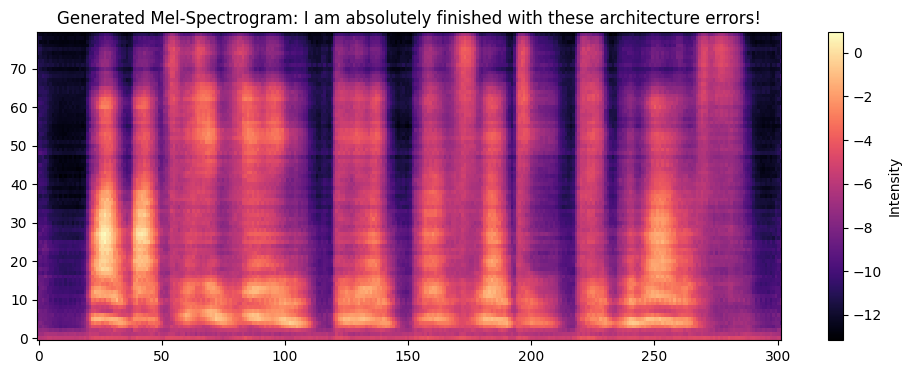

🔊 Converting Mel to Audio (Griffin-Lim)...
🌉 Bridging Mel to Linear frequencies...
🌊 Reconstructing Waveform...


✅ Done! You can finally hear your Angry AI.


In [ ]:
import matplotlib.pyplot as plt
from IPython.display import display, Audio

# 1. GENERATE the Mel-spectrogram
test_text = "I am absolutely finished with these architecture errors!"
print(f"🎤 Synthesizing: '{test_text}'...")

# Using your optimized settings: low temperature for stability, short length for anger
mel_output = speak(test_text, temperature=0.1, length_scale=0.85)

if mel_output is not None:
    # 2. PLOT the Mel
    plt.figure(figsize=(12, 4))
    plt.imshow(mel_output[0], aspect='auto', origin='lower', interpolation='none', cmap='magma')
    plt.colorbar(label='Intensity')
    plt.title(f"High-Res Mel-Spectrogram: {test_text}")
    plt.show()

    # 3. CONVERT to Audio (HiFi-GAN)
    print("🚀 Running HiFi-GAN Inference (Neural Vocoding)...")
    
    # Matcha outputs are Log-Mel, which HiFi-GAN loves.
    # We just need to ensure it's a Tensor on the same device as the vocoder.
    with torch.no_grad():
        mel_tensor = torch.FloatTensor(mel_output)
        # HiFi-GAN expects [Batch, 80, Time]
        waveform = vocoder(mel_tensor)
    
    # 4. DISPLAY the Audio Player
    # HiFi-GAN v1 outputs at 22050Hz
    display(Audio(waveform.squeeze().numpy(), rate=22050))
    print("✨ Success! You should hear a much more human 'Angry' voice now.")
else:
    print("❌ Synthesis failed. Ensure your 'last.ckpt' is loaded correctly.")